# Trading Engine

### From seven CSV exports to a set of decisions, and an argument about which of them a machine should be allowed to make on its own

A UK supplements brand's twelve months of Shopify, Meta, Google and Klaviyo
exports go in. What comes out is not a dashboard. It is a short list of specific
actions, each with the evidence behind it, a simulated range of outcomes, and a
verdict on whether the engine should take it unsupervised or hand it to a person.

The interesting part of this dataset is not the numbers, which are unremarkable
for a brand of this size. It is that the two largest movements in it are both
things you should not act on. Repeat purchasing appears to collapse to zero, and
average order value falls 8%. An engine that reported those as its top findings
would be doing exactly what it was built to do and would still be wrong. Most of
the work here is in the machinery that tells the difference.

**Reading order.** Sections 1 to 3 establish what the data can and cannot
support. Section 4 is the one worth reading if you only read one. Sections 5 to
8 are the decision pipeline. Section 9 is what I would do next and what I would
not claim.

**To run it.** `pip install -r requirements.txt`, then `python -m src.build`,
then run this notebook top to bottom. It takes about thirty seconds.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import WAREHOUSE_PATH
from src.warehouse import connect, query, quality_scores

if not WAREHOUSE_PATH.exists():
    from src.build import build
    build(verbose=False).close()

con = connect()

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 160)

INK, MUTED, WARN, GOOD = "#1f2933", "#9aa5b1", "#c0392b", "#1e7f5c"
plt.rcParams.update({
    "figure.figsize": (11, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelsize": 9,
    "font.size": 9,
    "legend.frameon": False,
})


def gbp(ax, axis="y", dp=0):
    fmt = mticker.FuncFormatter(lambda v, _: f"£{v:,.{dp}f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)


def pct(ax, axis="y"):
    fmt = mticker.FuncFormatter(lambda v, _: f"{v:.0%}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

---

## 1. The business, briefly

Before anything else, what does a normal day look like here. This matters
because every threshold later in the pipeline is calibrated against normal
variation, and normal variation for this brand is wide.

In [2]:
daily = query(con, '''
    SELECT date_day, net_revenue, net_revenue_ma7, orders, new_customers,
           gross_profit, aov, aov_ma28, is_peak_season
    FROM semantic.daily_business_metrics
    ORDER BY date_day
''')

headline = query(con, '''
    SELECT sum(net_revenue)                                     AS net_revenue,
           sum(gross_profit)                                    AS gross_profit,
           sum(gross_profit) / sum(net_revenue)                 AS gross_margin,
           sum(orders)                                          AS orders,
           sum(new_customers)                                   AS new_customers,
           sum(net_revenue) / sum(orders)                       AS aov
    FROM semantic.daily_business_metrics
''').iloc[0]

print(f"Twelve months to 30 June 2025")
print(f"  Net revenue (ex VAT)   £{headline.net_revenue:>12,.0f}")
print(f"  Gross profit           £{headline.gross_profit:>12,.0f}   ({headline.gross_margin:.0%} margin)")
print(f"  Orders                  {headline.orders:>12,.0f}")
print(f"  New customers           {headline.new_customers:>12,.0f}")
print(f"  Average order value    £{headline.aov:>12,.2f}")

Twelve months to 30 June 2025
  Net revenue (ex VAT)   £   1,258,296
  Gross profit           £     902,470   (72% margin)
  Orders                        25,720
  New customers                 20,284
  Average order value    £       48.92


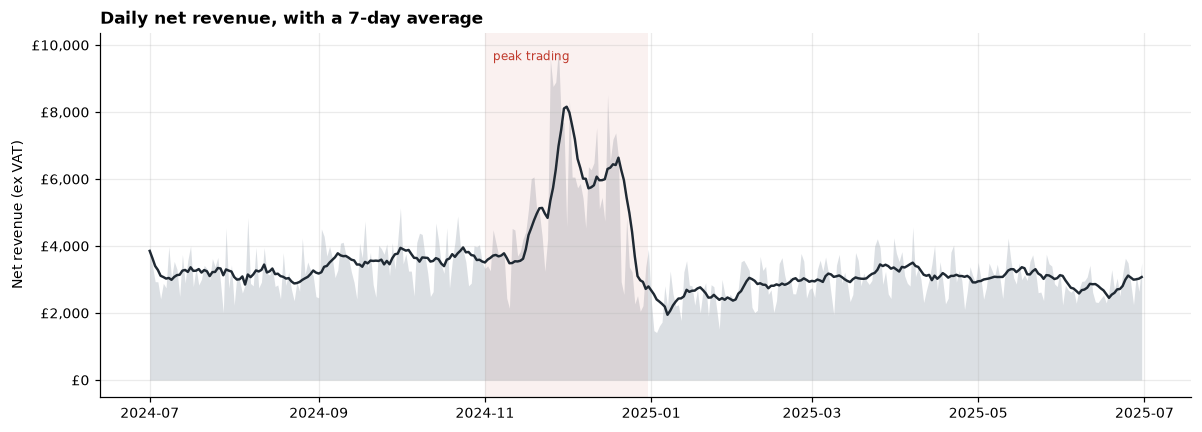

In [3]:
fig, ax = plt.subplots()
ax.fill_between(daily.date_day, daily.net_revenue, color=MUTED, alpha=0.35, lw=0)
ax.plot(daily.date_day, daily.net_revenue_ma7, color=INK, lw=1.6)

peak = daily[daily.is_peak_season]
if not peak.empty:
    ax.axvspan(peak.date_day.min(), peak.date_day.max(), color=WARN, alpha=0.07, lw=0)
    ax.text(peak.date_day.min(), ax.get_ylim()[1] * 0.95, "  peak trading",
            color=WARN, fontsize=8, va="top")

ax.set_title("Daily net revenue, with a 7-day average")
ax.set_ylabel("Net revenue (ex VAT)")
gbp(ax)
plt.tight_layout()

Two features of this chart set up everything that follows.

The **day-to-day spread is enormous** relative to the trend. A single day can sit
40% above or below its own weekly average without anything having happened. Any
detector that fires on a single bad day will fire constantly, which is why every
threshold in this project is paired with a persistence requirement rather than
used alone.

The **November and December peak is large enough to distort any comparison that
straddles it**. A channel that looked efficient in December looked that way partly
because demand was high, and assuming June behaves like December is a reliable
way to make a reallocation disappoint. This shows up later as an explicit
haircut on peak-season evidence.

---

## 2. What is wrong with the data, established before anything is built on it

Data quality here is not a preliminary tidying step. It is an input to every
decision the engine makes, because the checks below determine which metrics are
allowed to drive a recommendation at all.

Twenty-seven assertions run as part of the build. They fall into two groups, and
the distinction is the whole point. **Errors** stop the build: if order lines do
not tie to their headers, nothing downstream is worth computing. **Known issues**
are failures that were investigated, understood, and are expected to fail
permanently; they do not stop the build, they change what the affected metrics
are permitted to be used for.

In [4]:
checks = query(con, '''
    SELECT check_name, check_category, severity, is_known_issue, subject_metric,
           observed_value, passed, description
    FROM dq.check_results
    ORDER BY passed, is_known_issue DESC, check_name
''')

print(f"{len(checks)} checks: {checks.passed.sum()} pass, "
      f"{(~checks.passed).sum()} fail (all {(~checks.passed & checks.is_known_issue).sum()} "
      f"failures are documented known issues)\n")

failed = checks[~checks.passed][["check_name", "subject_metric", "observed_value", "description"]]
failed.style.hide(axis="index")

27 checks: 20 pass, 7 fail (all 7 failures are documented known issues)



check_name,subject_metric,observed_value,description
attribution_coverage,attribution,0.268429,"Share of valid orders with no usable referrer. Expected around 0.27, which is why channel CAC is reported as a range rather than a point estimate"
customer_order_count_reconciles,retention,825.000000,"Customers whose exported order_count disagrees with a recomputed count. Expected: the export counts cancelled orders while total_spent excludes them, which is why neither exported column is used downstream"
meta_spend_has_no_missing_days,channel_efficiency,2.000000,"Calendar days with no Meta spend row. Expected: 2025-03-15 and 2025-03-16 are absent for all six campaigns, roughly 793 GBP of unrecorded spend"
order_email_matches_customer_email,attribution,22810.000000,"Orders whose email disagrees with the customer record. Expected: orders.csv is redacted to @mail.com, which is why email is never used as a join key"
paid_traffic_has_spend_data,channel_efficiency,2318.000000,"Orders attributed to a paid channel with no spend file. Expected: TikTok sends traffic but supplies no cost data, so its CAC is uncomputable"
recent_cohorts_show_repeat_purchasing,ltv,5.000000,"Mature cohorts with effectively zero 90-day repeat rate. Expected: every cohort from December 2024 onward, which is a generation artifact rather than churn and is why LTV is excluded from the unit economics"
repeat_purchasing_spread_across_cohorts,ltv,0.982577,"Share of 2025 repeat orders coming from the first three cohorts. Expected around 0.98, far beyond what a real customer base would produce"


Seven failures, and none of them is a bug to be fixed. Each one is a constraint
on what can honestly be claimed:

**27% of orders have no usable referrer.** This is the most consequential one. It
means no channel's cost per acquisition is a single number. Every CAC in this
project is reported as a range: a pessimistic bound that credits a channel only
with orders provably attributable to it, and an optimistic bound that shares out
the unattributed pool. A recommendation is only made where the conclusion holds
at both ends.

**TikTok sends traffic and supplies no cost data.** Its CAC is not high or low, it
is uncomputable, and the engine says so rather than treating it as zero.

**Two days of Meta spend are missing** (15 and 16 March, roughly £793). Small
enough not to change any conclusion, large enough that it should be stated
rather than silently interpolated.

**Every cohort from December onward shows zero repeat purchasing**, and repeat
orders are concentrated in a handful of early cohorts. Two checks, one finding.
This is the one that matters, and section 4 is about it.

**Order emails are redacted to `@mail.com` and disagree with the customer
record.** Harmless in itself, but it rules out email as a join key, so orders are
tied to customers by id only.

**`customers.csv` ships pre-aggregated `order_count` and `total_spent` columns
that disagree with each other.** The export counts cancelled orders in one and
excludes them from the other. Neither is used downstream; both are recomputed
from the order table.

The checks feed a quality score per metric family, and that score is not
advisory. It caps the confidence of any recommendation built on that family:

In [5]:
scores = pd.DataFrame(
    sorted(quality_scores(con).items(), key=lambda kv: kv[1]),
    columns=["metric family", "quality score"],
)
scores.style.hide(axis="index").bar(subset=["quality score"], color="#d6e4ec", vmin=0, vmax=1)

metric family,quality score
ltv,0.000000
attribution,0.700000
channel_efficiency,0.800000
retention,0.900000
email_engagement,1.000000
margin,1.000000
product_velocity,1.000000
revenue,1.000000


`ltv` scores zero. That is not a rounding artifact, it is the mechanism that
makes it impossible to write a lifetime-value recommendation on this dataset
regardless of how compelling the underlying chart looks.

---

## 3. What the engine noticed

Seven detectors run over the semantic layer: cost-per-click inflation, payback
breach, product velocity change, inventory risk, average order value
decomposition, email engagement divergence, and the cohort adjudication.

Each detector emits signals with a **classification**, which is the part that
does the work. A signal is not simply "something moved". It is a claim about
*what kind of thing* moved, and only one of the four kinds is actionable as
stated:

| Classification | Meaning | What happens to it |
|---|---|---|
| `commercial` | The business genuinely changed | Eligible for a recommendation |
| `data_quality` | The measurement changed, not the business | Routed to engineering |
| `artifact` | An artifact of how the data was produced | Explicitly suppressed, with reasoning |
| `explained` | Real, but fully accounted for by another signal | Reported, not acted on separately |

In [6]:
from src.detection.runner import detect_all, signals_to_frame

signals = detect_all(con)
frame = signals_to_frame(signals)

frame[["signal_id", "classification", "entity", "metric", "detected_at",
       "magnitude", "persistence_days", "data_quality"]].style.hide(axis="index").format({
    "magnitude": "{:+.0%}", "data_quality": "{:.2f}",
})

signal_id,classification,entity,metric,detected_at,magnitude,persistence_days,data_quality
velocity_vit_d3_30ml,commercial,VIT-D3-30ML,units_per_day,2025-01-24,+175%,158,1.00
velocity_vit_d3_30ml_4k,commercial,VIT-D3-30ML-4K,units_per_day,2025-01-28,+150%,154,1.00
cpc_inflation_meta,commercial,Meta,cpc,2025-04-22,+142%,70,0.80
stockout_risk_vit_cbd20_30ml,commercial,VIT-CBD20-30ML,days_of_cover,2025-06-30,-62%,28,1.00
stockout_risk_vit_balm_100ml,commercial,VIT-BALM-100ML,days_of_cover,2025-06-30,-52%,28,1.00
payback_breach_meta,commercial,Meta,payback_ratio_7d,2025-06-03,-51%,16,0.80
stockout_risk_vit_balm_50ml,commercial,VIT-BALM-50ML,days_of_cover,2025-06-30,-32%,28,1.00
stockout_risk_vit_d3_30ml,commercial,VIT-D3-30ML,days_of_cover,2025-06-30,-26%,28,1.00
email_divergence_win_back,commercial,Win-Back,open_rate,2025-05-12,-16%,49,1.00
stockout_risk_vit_d3_30ml_4k,commercial,VIT-D3-30ML-4K,days_of_cover,2025-06-30,-2%,28,1.00


Seventeen signals. Note what is at the top and what is at the bottom.

The largest single movement in the dataset, `cohort_retention_collapse` at
-100%, is classified `artifact` and scores zero on data quality. The second
largest story by number of affected entities, the four email flows, is
consolidated into one `data_quality` incident with the individual flows demoted
to `explained`. Four separate alerts about four separate flows would have been
four separate investigations into one root cause.

---

## 4. The finding that would have been a mistake

This is the section I would read first.

Taken at face value, this dataset says the brand has stopped retaining
customers. The 90-day repeat rate falls from 32% for the July 2024 cohort to
exactly zero for every cohort from December onward. That is the largest, most
persistent, most statistically unambiguous signal available, and the obvious
output is an urgent retention programme.

It is also almost certainly false, and the engine has to be able to establish
that from evidence rather than from my prior about synthetic data. The
adjudicator runs three independent tests, each of which can discredit the naive
reading on its own.

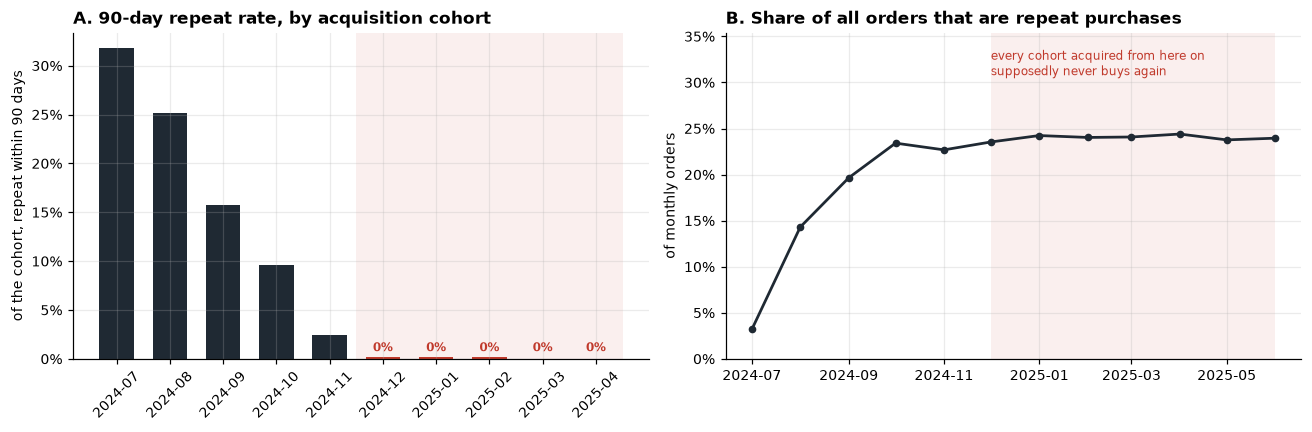

In [7]:
cohorts = query(con, '''
    SELECT cohort_month, cohort_size, repeat_rate_90d, has_full_90d_window
    FROM semantic.cohort_repeat_windows ORDER BY cohort_month
''')
brand = query(con, '''
    SELECT date_trunc('month', date_day)::DATE AS month_start,
           sum(repeat_orders)::DOUBLE / nullif(sum(orders), 0) AS repeat_share
    FROM semantic.daily_business_metrics GROUP BY 1 ORDER BY 1
''')

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))

mature = cohorts[cohorts.has_full_90d_window]
labels = mature.cohort_month.astype(str).str[:7]
is_zero = mature.repeat_rate_90d < 0.01
zero_from = list(labels).index(labels[is_zero].iloc[0])

left.axvspan(zero_from - 0.5, len(labels) - 0.5, color=WARN, alpha=0.08, lw=0)
left.bar(labels, mature.repeat_rate_90d, width=0.65,
         color=[WARN if z else INK for z in is_zero])
# The zero bars have no height, so without a label the finding is invisible in
# the one chart that exists to show it.
for x, zero in enumerate(is_zero):
    if zero:
        left.annotate("0%", (x, 0), textcoords="offset points", xytext=(0, 5),
                      ha="center", fontsize=8, color=WARN, fontweight="bold")
left.set_title("A. 90-day repeat rate, by acquisition cohort")
left.set_ylabel("of the cohort, repeat within 90 days")
left.tick_params(axis="x", rotation=45)
pct(left)

zero_date = pd.Timestamp(mature.cohort_month[is_zero].iloc[0])
right.axvspan(zero_date, brand.month_start.max(), color=WARN, alpha=0.08, lw=0)
right.plot(brand.month_start, brand.repeat_share, color=INK, lw=1.8, marker="o", ms=4)
right.set_ylim(0, max(brand.repeat_share) * 1.45)
right.annotate("every cohort acquired from here on\nsupposedly never buys again",
               xy=(zero_date, max(brand.repeat_share) * 1.38), color=WARN,
               fontsize=8, va="top", ha="left")
right.set_title("B. Share of all orders that are repeat purchases")
right.set_ylabel("of monthly orders")
pct(right)

plt.tight_layout()

**Panel A alone would justify the retention programme. Panel B makes it
impossible.**

If no customer acquired after November ever came back, the repeat share of
overall orders would have to *fall* month by month as the early cohorts were
used up. There would be nobody left to make a repeat purchase.

Instead it climbs for three months, which is just a new brand accumulating
customers who *can* return, and then goes flat. It stays flat straight through
the shaded region, at 24% of orders with a coefficient of variation of 0.011
across those seven months. Every month in there is a month where the cohorts
capable of producing a repeat order supposedly contain nobody who makes one.

The opening ramp is worth a note, because the test originally measured flatness
across the whole year and failed. A new brand's repeat share has to rise at
first: in month one there is nobody who could yet be returning. Including that
ramp put the coefficient of variation at 0.29 and hid a genuinely flat period
behind it. Measuring only the months under suspicion is not a convenient
narrowing, it is the comparison the argument was always about.

Both facts cannot describe the same business. Here are the three tests and their
verdict:

In [8]:
verdict = next(s for s in signals if s.signal_id == "cohort_retention_collapse")

for name, result in [
    ("Mature cohorts at literally zero repeat purchasing",
     verdict.evidence["test_zero_cohorts"]),
    ("Repeat orders confined to the earliest cohorts",
     verdict.evidence["test_concentrated_in_early_cohorts"]),
    ("Brand-level repeat share flat while cohorts go to zero",
     verdict.evidence["test_brand_repeat_share_flat"]),
]:
    print(f"  [{'FAILS PLAUSIBILITY' if result else 'passes'}]  {name}")

print(f"\n  {verdict.evidence['cohorts_with_zero_repeat']} of "
      f"{verdict.evidence['mature_cohorts_tested']} mature cohorts at zero")
print(f"  {verdict.evidence['share_of_2025_repeats_from_first_3_cohorts']:.0%} of 2025 repeat "
      f"orders come from customers acquired in the first three months")
print(f"  over the {verdict.evidence['suspect_window_months']} months those dead cohorts cover, "
      f"brand repeat share holds at {verdict.evidence['brand_repeat_share_mean_over_suspect_window']:.0%} "
      f"(coefficient of variation "
      f"{verdict.evidence['brand_repeat_share_coefficient_of_variation']:.3f})")
print(f"\n  VERDICT: {verdict.classification.value.upper()}")

  [FAILS PLAUSIBILITY]  Mature cohorts at literally zero repeat purchasing
  [FAILS PLAUSIBILITY]  Repeat orders confined to the earliest cohorts
  [FAILS PLAUSIBILITY]  Brand-level repeat share flat while cohorts go to zero

  5 of 10 mature cohorts at zero
  98% of 2025 repeat orders come from customers acquired in the first three months
  over the 7 months those dead cohorts cover, brand repeat share holds at 24% (coefficient of variation 0.011)

  VERDICT: ARTIFACT


98% of 2025's repeat orders come from customers acquired in the first three
months of the dataset. Repeat purchasing is not a behaviour of this customer
base; it is a property of a fixed group baked in when the data was generated.

**The consequence is deliberately expensive.** Lifetime value cannot be measured
here, so the whole LTV:CAC framework, which is the standard way to judge
acquisition spend, is unavailable. Every unit-economics judgement in this
project falls back to first-order contribution margin: does the gross profit on
a customer's first order cover what it cost to acquire them. That is a stricter
test than LTV:CAC and it understates the value of a good channel, but it is the
strongest claim this data supports.

The important property is that **this is a test, not an assumption**. The same
code run against production data where the collapse was real would find the
brand-level repeat share falling in step with the cohorts, would fail to find
the concentration in early cohorts, and would return `COMMERCIAL`.

---

## 5. The case that does survive scrutiny

Meta's cost per click more than doubled from late April, rising 142% from about
£0.43 to £1.04, and stayed there. On its own that
is a price change, not a problem: a channel can get more expensive and still be
the best place to spend. What makes it actionable is the second signal, which is
that the gross profit on a new Meta customer's first order stopped covering what
it cost to acquire them.

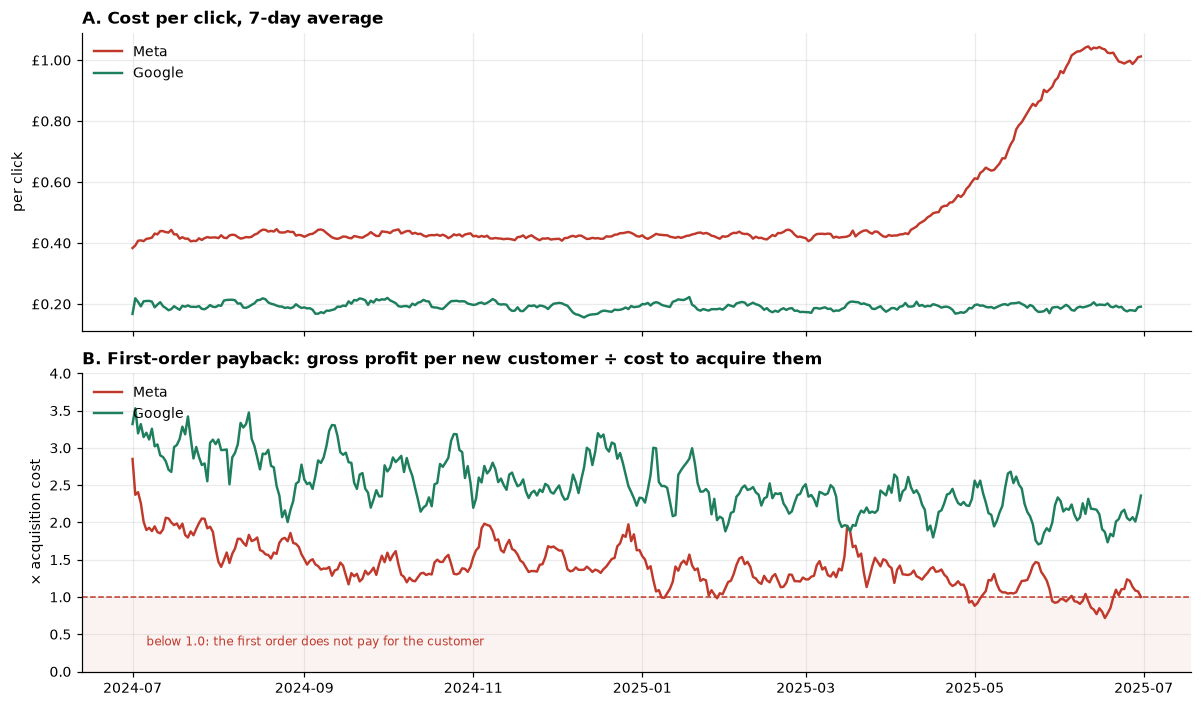

In [9]:
channel = query(con, '''
    SELECT date_day, channel, spend, cpc_ma7, cac_attributed_7d,
           cac_with_unattributed_7d, payback_ratio_7d
    FROM semantic.channel_daily_performance
    WHERE channel IN ('Meta', 'Google')
    ORDER BY channel, date_day
''')
meta = channel[channel.channel == "Meta"]
google = channel[channel.channel == "Google"]

fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

top.plot(meta.date_day, meta.cpc_ma7, color=WARN, lw=1.6, label="Meta")
top.plot(google.date_day, google.cpc_ma7, color=GOOD, lw=1.6, label="Google")
top.set_title("A. Cost per click, 7-day average")
top.set_ylabel("per click")
top.legend(loc="upper left")
gbp(top, dp=2)

bottom.axhspan(0, 1, color=WARN, alpha=0.06, lw=0)
bottom.axhline(1.0, color=WARN, lw=1, ls="--")
bottom.plot(meta.date_day, meta.payback_ratio_7d, color=WARN, lw=1.6, label="Meta")
bottom.plot(google.date_day, google.payback_ratio_7d, color=GOOD, lw=1.6, label="Google")
bottom.set_title("B. First-order payback: gross profit per new customer ÷ cost to acquire them")
bottom.set_ylabel("× acquisition cost")
bottom.set_ylim(0, 4)
bottom.text(meta.date_day.iloc[5], 0.35, "below 1.0: the first order does not pay for the customer",
            color=WARN, fontsize=8)
bottom.legend(loc="upper left")

plt.tight_layout()

Panel B is the one that authorises action. Meta crosses below 1.0 and oscillates
there; Google holds comfortably above it throughout.

The detector for this deliberately does **not** require an unbroken run of days
below the line. Meta's payback ratio crosses back above 1.0 on individual good
days, and an unbroken-run rule would reset on each of them and never fire. The
test used instead asks whether the majority of a window is in breach with a
minimum consecutive run inside it, which is what a sustained problem actually
looks like in a noisy series.

Because attribution is incomplete, the comparison is checked at both ends of the
range rather than at a point estimate:

In [10]:
economics = query(con, '''
    SELECT month_start, channel, spend, new_customers,
           cac_attributed, cac_with_unattributed,
           contribution_per_new_customer,
           payback_ratio_pessimistic, payback_ratio_optimistic
    FROM semantic.channel_unit_economics
    WHERE month_start >= DATE '2025-04-01'
    ORDER BY month_start, channel
''')
economics.style.hide(axis="index").format({
    "spend": "£{:,.0f}", "cac_attributed": "£{:,.2f}", "cac_with_unattributed": "£{:,.2f}",
    "contribution_per_new_customer": "£{:,.2f}",
    "payback_ratio_pessimistic": "{:.2f}", "payback_ratio_optimistic": "{:.2f}",
    "new_customers": "{:,.0f}",
})

month_start,channel,spend,new_customers,cac_attributed,cac_with_unattributed,contribution_per_new_customer,payback_ratio_pessimistic,payback_ratio_optimistic
2025-04-01 00:00:00,Google,"£8,000",573,£13.96,£10.15,£32.07,2.30,3.16
2025-04-01 00:00:00,Meta,"£11,772",433,£27.19,£19.80,£32.80,1.21,1.66
2025-05-01 00:00:00,Google,"£8,634",562,£15.36,£11.08,£34.00,2.21,3.07
2025-05-01 00:00:00,Meta,"£13,873",476,£29.14,£21.05,£33.66,1.15,1.60
2025-06-01 00:00:00,Google,"£7,462",489,£15.26,£10.95,£32.42,2.12,2.96
2025-06-01 00:00:00,Meta,"£13,027",375,£34.74,£25.06,£33.51,0.96,1.34


Meta is worse than Google on the pessimistic bound and worse on the optimistic
bound. The gap does not depend on how the unattributed 27% is allocated, which
is precisely what makes it safe to act on.

---

## 6. From signals to decisions

Rules turn signals into proposed actions. Each carries a confidence score built
from four factors, and how those four combine is a deliberate choice worth
stating.

Three of them, **strength**, **persistence** and **corroboration**, describe how
good the evidence is, and are averaged. The fourth, **data quality**, multiplies
that average instead of joining it.

Averaging all four would let a huge, persistent, well-corroborated signal built
on broken data score around 0.7, because three strong terms outvote one weak
one. But those three terms are all computed *from* the suspect data. They are
not independent evidence, they are the same doubt counted three more times.
Multiplying makes data quality a ceiling. It is what mechanically prevents a
retention recommendation here, where the collapse is enormous, perfectly
persistent, and entirely fictional.

In [11]:
from src.recommendations.engine import recommend, recommendations_to_frame

recommendations = recommend(signals, con)
recommendations_to_frame(recommendations).style.hide(axis="index")

recommendation_id,title,action_type,reversibility,confidence,signals
restock_cbd_muscle_balm,"Reorder CBD Muscle Balm: 602 units, GBP 3,846",inventory_purchase,irreversible,1.000000,"stockout_risk_vit_balm_100ml, stockout_risk_vit_balm_50ml"
restock_cbd_oil_20%,"Reorder CBD Oil 20%: 752 units, GBP 21,056",inventory_purchase,irreversible,1.000000,stockout_risk_vit_cbd20_30ml
investigate_d3_mix_economics,Establish whether the Vitamin D3 surge is recruiting customers or diluting them,investigation,reversible,1.000000,"velocity_vit_d3_30ml, aov_decline"
restock_vitamin_d3_drops,"Reorder Vitamin D3 Drops: 2,012 units, GBP 6,263",inventory_purchase,irreversible,0.883000,"stockout_risk_vit_d3_30ml, stockout_risk_vit_d3_30ml_4k, velocity_vit_d3_30ml, velocity_vit_d3_30ml_4k"
reallocate_meta_to_google,"Move GBP 2,282 of monthly Meta budget to Google",budget_reallocation,reversible,0.800000,"cpc_inflation_meta, payback_breach_meta"
investigate_email_tracking,Investigate email open and click tracking as an infrastructure fault,investigation,reversible,0.739000,email_tracking_incident_account
refresh_flow_win_back,Rebuild the Win-Back email flow,flow_optimisation,reversible,0.730000,email_divergence_win_back
no_action_aov_decline,"No action: falling order value is product mix, not pricing",no_action,reversible,0.666000,aov_decline
no_action_cohort_retention_collapse,No action: repeat_rate_90d movement is a data artifact,no_action,reversible,0.000000,cohort_retention_collapse


In [12]:
def show(recommendation, width=88):
    import textwrap
    wrap = lambda t, i="": textwrap.fill(t, width, initial_indent=i, subsequent_indent=i)
    print(f"{recommendation.title}")
    print("=" * width)
    print(f"{recommendation.action_type.value} | {recommendation.reversibility.value} | "
          f"confidence {recommendation.confidence.overall:.2f}")
    print(f"  ({recommendation.confidence.explain()})\n")
    print("ACTION"); print(wrap(recommendation.action, "  ")); print()
    print("WHY")
    for para in recommendation.rationale.split("\n\n"):
        print(wrap(para, "  ")); print()
    if recommendation.caveats:
        print("WHAT WOULD MAKE THIS WRONG")
        for caveat in recommendation.caveats:
            print(wrap(f"- {caveat}", "  "))


show(next(r for r in recommendations if r.recommendation_id == "reallocate_meta_to_google"))

Move GBP 2,282 of monthly Meta budget to Google
budget_reallocation | reversible | confidence 0.80
  (strength 1.00, persistence 1.00, corroboration 1.00 -> evidence 1.00, scaled by data quality 0.80 = 0.80)

ACTION
  Reduce Meta spend by GBP 2,282 a month (18% of current Meta budget) and add the same
  amount to Google. Implement over two weeks rather than at once, and stop if Google's
  cost per acquisition rises above GBP 18.31.

WHY
  Meta now costs GBP 34.74 to acquire a customer against GBP 15.26 on Google, so the
  same money buys roughly 2.3 times as many customers on Google. Meta's cost per click
  has risen 142% since 22 April, and gross profit on a new Meta customer's first order
  no longer covers what it costs to acquire them. Google's economics have been stable
  throughout the same period.

  The amount is capped by evidence rather than ambition. Google has previously absorbed
  GBP 12,026 in a month while staying profitable, which is GBP 4,564 above its current
  spend,

Two details in that output are load-bearing.

The size of the move is **capped by evidence rather than by ambition**. Google's
headroom is set by the most it has ever absorbed in a month while staying
profitable, and because that month was December, the headroom is discounted by
half. Assuming June behaves like Christmas is the standard way a reallocation
underdelivers.

And the recommendation ships with the conditions that would make it wrong,
including the one that argues against it: last-click attribution systematically
underrates upper-funnel channels, so Meta's true contribution may be higher than
measured. That caveat is not decoration. Section 8 prices it.

The engine also makes a point of saying what it deliberately did **not** do:

In [13]:
show(next(r for r in recommendations if r.recommendation_id == "no_action_aov_decline"))

No action: falling order value is product mix, not pricing
no_action | reversible | confidence 0.67
  (strength 0.16, persistence 1.00, corroboration 1.00 -> evidence 0.67, scaled by data quality 1.00 = 0.67)

ACTION
  Do not change pricing or promotions in response to the fall in average order value.
  Address it through the product mix question instead.

WHY
  Average order value has fallen 8%, from GBP 50.44 to GBP 46.28. This is a product mix
  effect, not a pricing or promotions problem: basket size is unchanged (-0.2%) and the
  discount rate is unchanged (-2.0%), while average unit price has fallen 9% as sales
  shift toward cheaper products. No promotional action is warranted.

  This is called out because the obvious response to falling order value is a
  promotional or pricing change, and here that would be aimed at something that is not
  happening. Discounting is flat and baskets are the same size; customers are simply
  buying a cheaper product more often.



Average order value fell 8%, and the reflex response is a promotion. The
decomposition shows basket size unchanged and the discount rate unchanged, with
the entire fall coming from mix as a cheaper product takes share. A promotion
would be aimed at something that is not happening.

Recording this as an explicit no-action matters because silence and oversight
look identical from outside. If the engine simply omitted average order value,
the reasonable assumption would be that it missed it.

---

## 7. What happens if we do it

Each cash-generating recommendation is simulated over 10,000 draws. Inputs are
block-bootstrapped from the brand's own recent daily history rather than drawn
from fitted distributions: daily ecommerce series are skewed and autocorrelated,
and a fitted normal produces tidy intervals that understate how bad a bad
quarter can be. Seven-day blocks preserve the clustering of good and bad weeks.

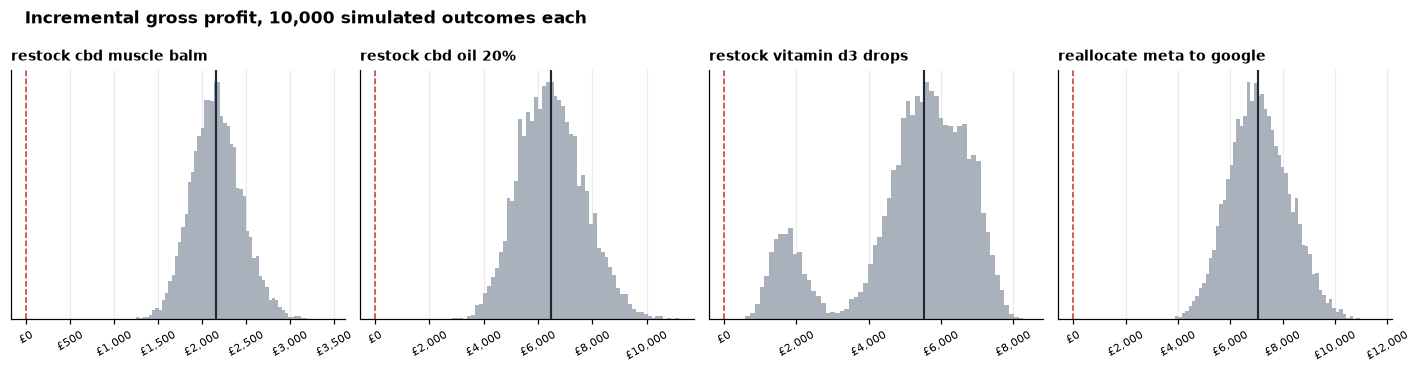

In [14]:
from src.simulation import simulate_all

nominal = simulate_all(recommendations, con)
stressed = simulate_all(recommendations, con, stress=True)

fig, axes = plt.subplots(1, len(nominal), figsize=(13, 3.4), sharey=False)
for ax, (rec_id, result) in zip(np.atleast_1d(axes), nominal.items()):
    ax.hist(result.samples, bins=60, color=MUTED, alpha=0.85, lw=0)
    ax.axvline(result.p50, color=INK, lw=1.4)
    ax.axvline(0, color=WARN, lw=1, ls="--")
    ax.set_title(rec_id.replace("_", " "), fontsize=9)
    ax.set_yticks([])
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    gbp(ax, axis="x")
fig.suptitle("Incremental gross profit, 10,000 simulated outcomes each", x=0.02, ha="left",
             fontsize=11, fontweight="bold")
plt.tight_layout()

In [15]:
for rec_id, result in nominal.items():
    print(f"{rec_id}\n  {result.summary()}\n")

restock_cbd_muscle_balm
  Incremental gross profit over 180 days: central estimate GBP 2,158, 90% credible interval GBP 1,723 to GBP 2,646, probability of a positive return 100%

restock_cbd_oil_20%
  Incremental gross profit over 180 days: central estimate GBP 6,468, 90% credible interval GBP 4,651 to GBP 8,575, probability of a positive return 100%

restock_vitamin_d3_drops
  Incremental gross profit over 180 days: central estimate GBP 5,527, 90% credible interval GBP 1,536 to GBP 7,203, probability of a positive return 100%

reallocate_meta_to_google
  Incremental gross profit over 90 days: central estimate GBP 7,068, 90% credible interval GBP 5,323 to GBP 9,056, probability of a positive return 100%



**Every one of them reports a 100% probability of a positive return, and that
should be the least convincing number on the page.**

A probability of 100% is a statement about the model. It means the model could
not generate a losing outcome, which is a fact about the model's inputs rather
than about the world. Two things are done about it.

First, the budget model reports the **break-even elasticity**: the value at which
the move stops paying. This is more useful than the probability, because it
converts "we are confident" into a claim someone with market knowledge can
argue with.

In [16]:
budget = nominal["reallocate_meta_to_google"]
print(budget.assumptions["breakeven_interpretation"])
print(f"\nSpend elasticity prior: {budget.assumptions['spend_elasticity_prior']}")

The move only loses money if the destination channel's elasticity exceeds 2.54. Values above 1.0 are not physically possible, since that would mean spending more wins fewer customers in absolute terms. This is why the probability of a positive return is so high: it is not model confidence, it is that the gap between the two channels' acquisition costs is too large for diminishing returns to close.

Spend elasticity prior: Beta(2, 4) on [0, 1], mean 0.33 - assumed, not estimable from this data


Elasticity here is the rate at which acquisition gets more expensive as spend
rises. Zero means the channel absorbs extra budget at unchanged efficiency; 1.0
means the extra budget wins no extra customers at all. Above 1.0 is not
physically possible, because spending more cannot win you fewer customers in
absolute terms.

The break-even value is 2.54. The move is not robust because the model is
confident, it is robust because the gap between the two channels' acquisition
costs is too wide for any possible amount of diminishing returns to close.

**Worth being explicit about what could not be estimated.** That elasticity is an
assumed prior, not a measurement, and it cannot be measured from this data.
Google's monthly spend correlates 0.993 with total order volume: budget follows
demand. Regressing acquisition cost on spend therefore measures the seasonal
cycle rather than the auction's response to money, and duly returns a slope of
-0.018, implying customers get *cheaper* the more you spend. No amount of
additional modelling fixes that. It needs a deliberate budget experiment that
varies spend independently of demand.

Second, and more generally, every model is re-run with its most fragile
assumptions set against it. That is section 8.

---

## 8. Which of these should a machine do by itself

The gate answers a different question from everything before it. Not "is this
recommendation good", which is settled, but "should the engine act on its own
belief without asking".

Those come apart. Four recommendations carry a 100% modelled probability of a
positive return and exactly one of them auto-executes.

The organising principle is that **the cost of being wrong is not symmetric**.
Shifting ad budget can be undone within a day and the damage stops when you
notice. Committing cash to stock cannot be undone at all: the money is gone, the
goods occupy space, they age toward expiry, and the only exit is discounting.
Two actions with identical expected value deserve different treatment.

So the gate asks two questions, and both must pass:

- **Is it likely to be right?** Confidence, probability of a positive return, and
  a loss-adjusted value that weights the downside rather than averaging it away.
- **Is being wrong survivable?** The same simulation re-run with its assumptions
  set against it, measured against what the business can absorb, and against
  whether there is any way back.

In [17]:
from src.autonomy import decisions_to_frame, evaluate_all

decisions = evaluate_all(recommendations, con)
decisions_to_frame(decisions).style.hide(axis="index")

recommendation_id,verdict,exposure_gbp,authorised_now_gbp,worst_case_cost_gbp,needs_scrutiny,failed_checks
restock_cbd_muscle_balm,propose,3846.000000,nan,260.000000,False,action_is_reversible
restock_cbd_oil_20%,propose,21056.000000,nan,3108.000000,True,"stressed_case_is_affordable, action_is_reversible"
investigate_d3_mix_economics,escalate,0.000000,nan,nan,False,-
restock_vitamin_d3_drops,propose,6263.000000,nan,3759.000000,True,"stressed_case_is_affordable, action_is_reversible"
reallocate_meta_to_google,auto_execute,2282.000000,1024.000000,157.000000,False,within_autonomous_step_size
investigate_email_tracking,escalate,0.000000,nan,nan,False,-
refresh_flow_win_back,escalate,0.000000,nan,nan,False,-
no_action_aov_decline,suppress,0.000000,nan,nan,False,-
no_action_cohort_retention_collapse,suppress,0.000000,nan,nan,False,-


Each stress attacks an assumption the recommendation already lists as a caveat.
That is the point: a caveat that never changes a decision is decoration.
Re-running the model under the adverse setting turns each one into a number.

For the budget move, the stress is that Google absorbs the extra spend at the
worst response physically possible *and* every unattributed order turns out to
have been Meta's. That second one is the "last-click underrates upper-funnel"
caveat, priced.

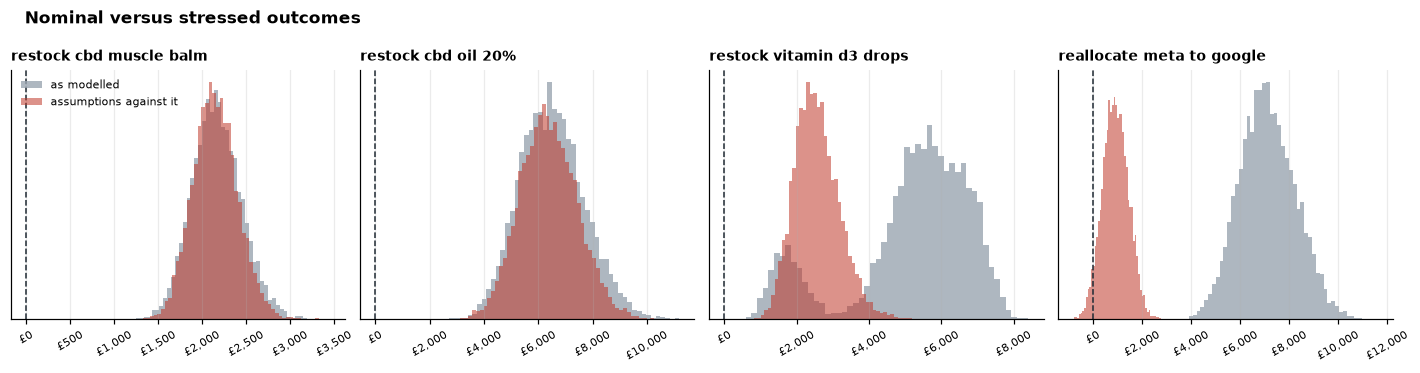

In [18]:
fig, axes = plt.subplots(1, len(nominal), figsize=(13, 3.4))
for ax, rec_id in zip(np.atleast_1d(axes), nominal):
    ax.hist(nominal[rec_id].samples, bins=50, color=MUTED, alpha=0.8, lw=0, label="as modelled")
    ax.hist(stressed[rec_id].samples, bins=50, color=WARN, alpha=0.55, lw=0, label="assumptions against it")
    ax.axvline(0, color=INK, lw=1, ls="--")
    ax.set_title(rec_id.replace("_", " "), fontsize=9)
    ax.set_yticks([])
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    gbp(ax, axis="x")
np.atleast_1d(axes)[0].legend(fontsize=7, loc="upper left")
fig.suptitle("Nominal versus stressed outcomes", x=0.02, ha="left", fontsize=11, fontweight="bold")
plt.tight_layout()

The budget move survives its stress test with the central outcome falling from
about £7,100 to about £900. It still clears zero, and it is the only
recommendation the engine executes on its own.

In [19]:
def explain(decision, width=88):
    import textwrap
    wrap = lambda t, i="  ": textwrap.fill(t, width, initial_indent=i, subsequent_indent=i)
    print(f"{decision.recommendation_id}  ->  {decision.verdict.value.upper()}")
    print("=" * width)
    print(wrap(decision.headline)); print()
    for check in decision.checks:
        mark = "PASS" if check.passed else ("note" if not check.blocking else "FAIL")
        print(f"  [{mark:>4}] {check.name}")
        print(wrap(check.detail, "         "))
    print()
    print("  SAFEGUARD")
    print(wrap(decision.safeguard, "         "))


explain(decisions["reallocate_meta_to_google"])

reallocate_meta_to_google  ->  AUTO_EXECUTE
  The engine acts. GBP 1,024 authorised now, which is the first of 3 steps; the rest
  follows only if the measured result of this one clears the same tests. Reversible
  within a day under a monitored stop-loss, and even with its assumptions set against it
  the action stays profitable.

  [PASS] confidence_meets_bar
         Confidence 0.80 against a bar of 0.70 for reversible actions.
  [PASS] probability_of_positive_return
         100% of simulated outcomes are profitable, against a bar of 65%.
  [PASS] survives_asymmetric_loss
         Loss-adjusted value GBP 7,120, weighting losses 2.0x against gains. Plain
         expected value is GBP 7,120. The two are equal because no simulated draw loses
         money, so the penalty has nothing to bite on. That is a limitation of the
         simulation rather than a property of the decision, and it is why the stress
         test below carries the weight here.
  [PASS] stressed_case_is_afforda

Two things there are worth pulling out.

**The move is tranched rather than approved whole.** The engine takes £1,024 of
the £2,282 now, which is 5% of monthly paid media spend, and earns the rest on
measured results. This turns one decision it would have to be right about into
three it can be wrong about cheaply. It is also the honest way to discover
Google's real elasticity, which the data could not tell us: spend a small amount
more and watch what the auction does.

**The asymmetric loss weighting is inert here, and the gate says so.** Losses are
weighted at twice gains for reversible actions, but no simulated draw loses
money, so the penalty has nothing to bite on and the loss-adjusted value equals
the plain expected value. Presenting an untriggered safeguard as a passed test
would overstate how much scrutiny the number has had.

Now the contrast. Three restocks arrive together. All three score at or near
1.00 on confidence with a 100% modelled probability of profit. None
auto-executes, because none can be undone. But they are not equally
interesting, and the gate says which one deserves an argument rather than a
signature:

In [20]:
for rec_id in ["restock_cbd_muscle_balm", "restock_vitamin_d3_drops"]:
    explain(decisions[rec_id])
    print("\n")

restock_cbd_muscle_balm  ->  PROPOSE
  For approval, routine. Committing GBP 3,846 that cannot be recalled, but it holds up
  under a deliberately adverse reading of its own assumptions. The signature is required
  because the money is unrecoverable, not because the case is weak.

  [PASS] confidence_meets_bar
         Confidence 1.00 against a bar of 0.85 for irreversible actions.
  [PASS] probability_of_positive_return
         100% of simulated outcomes are profitable, against a bar of 80%.
  [PASS] survives_asymmetric_loss
         Loss-adjusted value GBP 2,167, weighting losses 5.0x against gains. Plain
         expected value is GBP 2,167. The two are equal because no simulated draw loses
         money, so the penalty has nothing to bite on. That is a limitation of the
         simulation rather than a property of the decision, and it is why the stress
         test below carries the weight here.
  [PASS] stressed_case_is_affordable
         With its key assumptions set against 

The CBD Muscle Balm order is routine. It needs a signature because £3,846 of
unrecoverable cash is a person's decision, not because the case is weak.

The Vitamin D3 order is the one to think about, and the reason is specific.
Its quantity is sized against demand that rose 175% since January. If that surge
unwinds, demand falls 57%, and **60% of the £6,263 is still sitting on the shelf
six months later**. The CBD Oil order commits three times as much cash and puts
15% of it at risk; the Muscle Balm order, 7%.

That ordering is the opposite of what every other number says. By confidence,
probability and expected value, Vitamin D3 is indistinguishable from the other
two. The distinction only appears when you ask what happens if the assumption
the order was sized on turns out to be wrong.

This one also arrives paired with an investigation the engine escalated
separately: whether the Vitamin D3 surge is recruiting customers who trade up,
or diluting the mix with a cheaper product. The engine cannot answer that,
because answering it requires measuring repeat purchasing, and section 4
established that repeat purchasing is exactly what this data cannot support.
Recommending an investigation rather than guessing is the correct output.

---

## 9. What I would not claim, and what I would do next

**Three numbers in this project are assumptions, not measurements**, and each one
is flagged on every output it touches:

- The **30-day supplier lead time**. Nothing in the dataset contains supplier
  terms, and every reorder quantity is directly proportional to it. This is the
  single highest-leverage unknown in the inventory recommendations.
- **Google's spend elasticity**. Unidentifiable from observational data where
  budget follows demand, as section 7 explains. Handled as a prior with the
  break-even value reported so the assumption can be argued with directly.
- The **15% probability that a demand surge reverts**. Bootstrapping recent
  history can only produce futures that look like the recent past, so it can
  never simulate the one scenario that makes a large stock purchase dangerous.
  Without this term every restock returned a 100% probability of profit, which
  was a property of the method rather than of the world.

**What the data cannot support at all:** lifetime value, cohort retention, any
LTV:CAC judgement, and TikTok's efficiency. Also incrementality. Everything here
is last-click correlation, so a channel that drives demand converting later
through direct or search is systematically underrated. The gate's tranched
rollout is a partial answer, since a small measured step is a cheap experiment.

**What I would build next, in order:**

1. **A budget holdout experiment.** One geographic region held at flat spend for
   six weeks would identify the elasticity the entire budget model currently
   assumes, and would convert the largest assumption in the project into a
   measurement.
2. **Inventory snapshot history.** Stock is a single current reading with no
   history, so it is impossible to tell whether a product has stocked out before
   or whether recent sales were already constrained by low stock. Recent
   velocity may be understated for exactly the products the engine is
   recommending reordering.
3. **Outcome tracking on the gate's own decisions.** Every auto-executed action
   ships with a rollback trigger, but nothing currently records whether the
   simulated interval contained the realised outcome. Without that the
   confidence scores can never be calibrated, and a confidence score that is
   never checked against reality is a number that drifts.

In [21]:
con.close()